# 📓 Regresión Lineal con Jupyter Notebook

Construye modelos predictivos de clima conectándote directamente a PostgreSQL, aplica un EDA completo y analiza los supuestos estadísticos de normalidad, homocedasticidad y multicolinealidad.

**Pipeline ETL WeatherStack** — datos sintéticos de 5 ciudades colombianas almacenados en PostgreSQL.

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

# Agrega la raíz del proyecto al path para importar scripts/
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Motor de base de datos reutilizando database.py del proyecto
from scripts.database import engine

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       2.4.3
   seaborn     0.13.2
   statsmodels 0.14.6


## Fase 2: Conexión a PostgreSQL desde el Notebook

Consultamos las tablas `registros_clima` y `ciudades` con un JOIN.

In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    c.nombre        AS ciudad,
    r.temperatura,
    r.sensacion_termica,
    r.humedad,
    r.velocidad_viento,
    r.fecha_extraccion
FROM registros_clima r
JOIN ciudades c ON r.ciudad_id = c.id
ORDER BY r.fecha_extraccion
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente desde PostgreSQL
   Filas    : 5,000
   Columnas : 6

📋 Primeras filas:


,ciudad,temperatura,sensacion_termica,humedad,velocidad_viento,fecha_extraccion
0,Bogotá,18.5,18.2,68.0,17.3,2026-03-21 12:45:00
1,Medellín,24.5,22.6,58.0,5.8,2026-03-21 12:45:00
2,Cali,33.0,31.6,59.0,9.1,2026-03-21 12:45:00
3,Barranquilla,38.0,37.3,70.0,24.1,2026-03-21 12:45:00
4,Cartagena,35.1,33.0,74.0,17.0,2026-03-21 12:45:00


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n🏙️  Ciudades en el dataset:")
print(df['ciudad'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ciudad             5000 non-null   object        
 1   temperatura        5000 non-null   float64       
 2   sensacion_termica  5000 non-null   float64       
 3   humedad            5000 non-null   float64       
 4   velocidad_viento   5000 non-null   float64       
 5   fecha_extraccion   5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 234.5+ KB
None

📊 Valores nulos por columna:
ciudad               0
temperatura          0
sensacion_termica    0
humedad              0
velocidad_viento     0
fecha_extraccion     0
dtype: int64

🏙️  Ciudades en el dataset:
ciudad
Bogotá          1000
Medellín        1000
Cali            1000
Barranquilla    1000
Cartagena       1000
Name: count, dtype: 

## Fase 3: EDA — Análisis Exploratorio de Datos

Antes de construir cualquier modelo, es fundamental entender la distribución, escala y relaciones entre las variables.

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['temperatura', 'sensacion_termica', 'humedad', 'velocidad_viento']

desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
desc

📊 ESTADÍSTICAS DESCRIPTIVAS


,temperatura,sensacion_termica,humedad,velocidad_viento
count,5000.00,5000.00,5000.00,5000.00
mean,25.66,24.17,75.92,15.43
std,7.58,7.60,8.62,5.21
min,6.30,3.40,54.00,0.80
25%,19.80,18.30,70.00,11.60
50%,27.00,25.40,76.00,15.05
75%,31.60,30.10,82.00,19.10
max,41.20,40.50,99.00,31.00


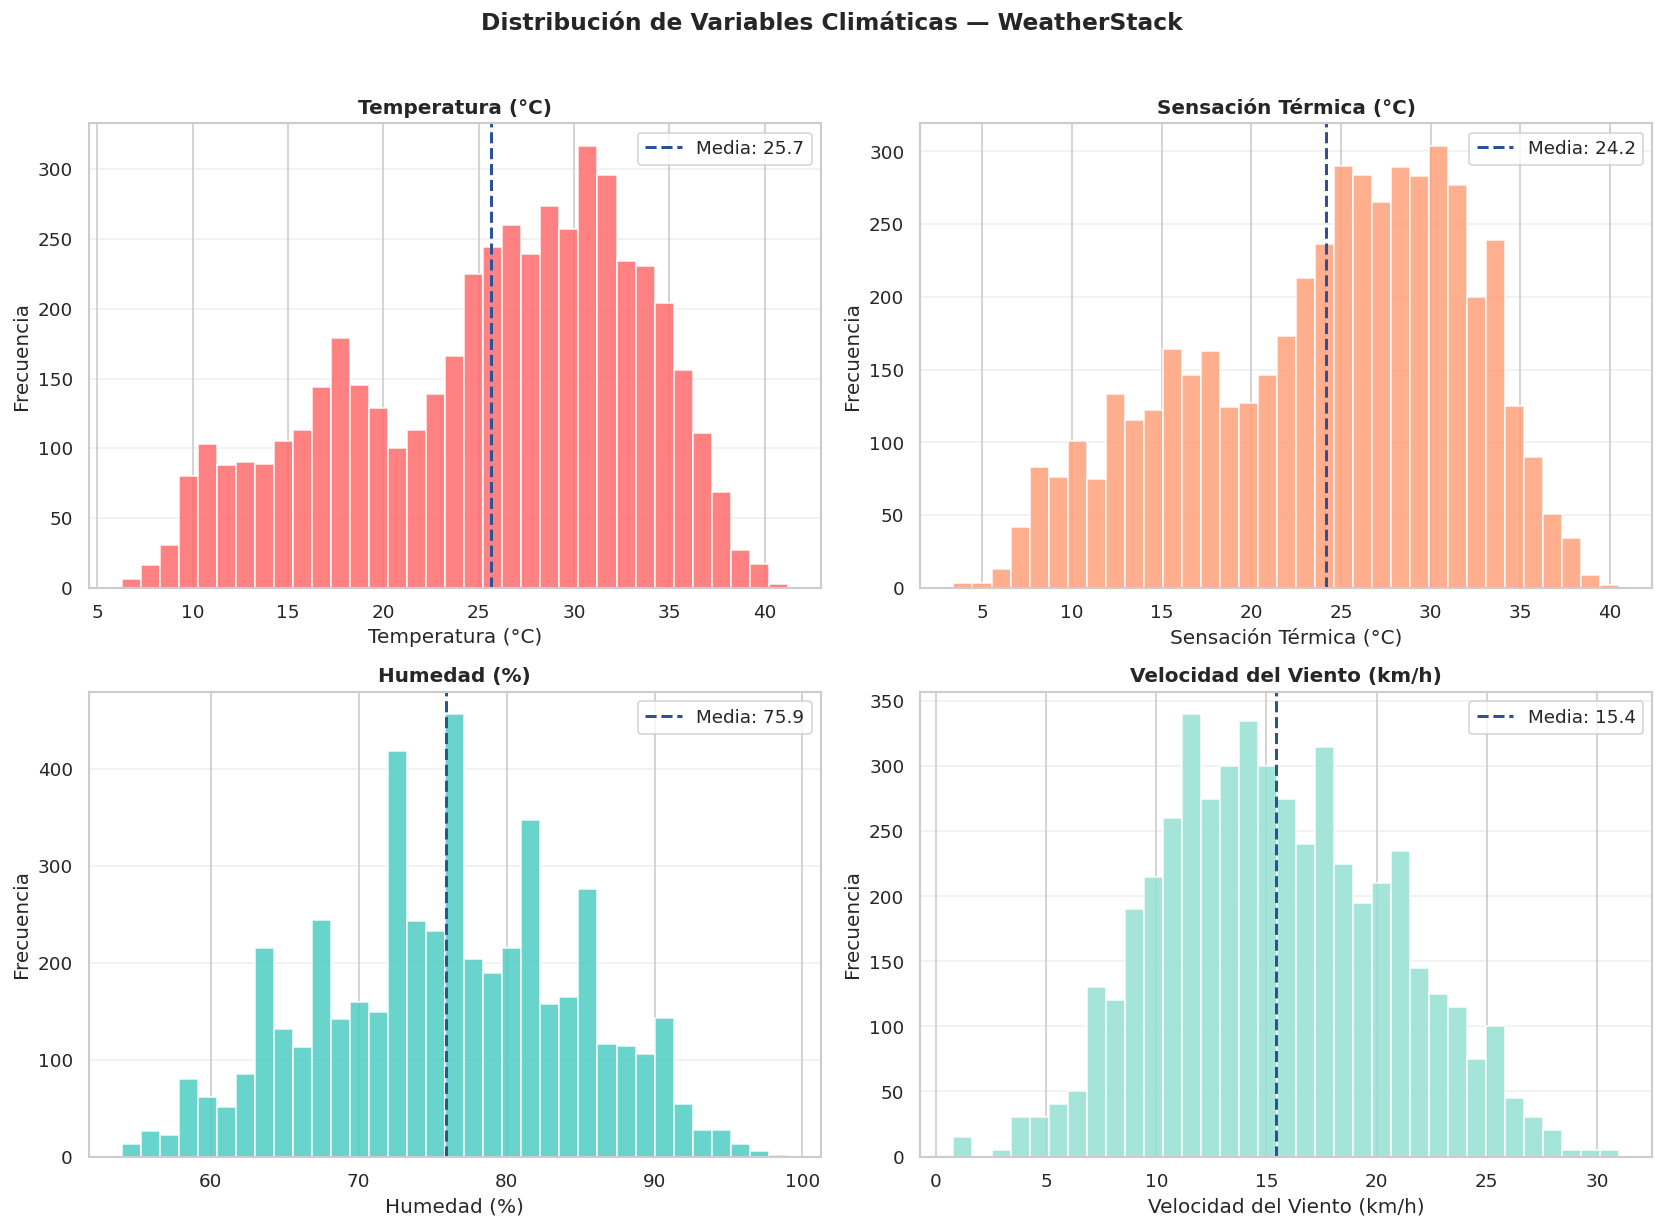

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Climáticas — WeatherStack',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'temperatura':       ('Temperatura (°C)',          '#ff6b6b'),
    'sensacion_termica': ('Sensación Térmica (°C)',     '#ffa07a'),
    'humedad':           ('Humedad (%)',                '#4ecdc4'),
    'velocidad_viento':  ('Velocidad del Viento (km/h)','#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_distribuciones.png',
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4079/2177733011.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ciudad', y='temperatura', order=orden,
/tmp/ipykernel_4079/2177733011.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ciudad', y='humedad', order=orden,


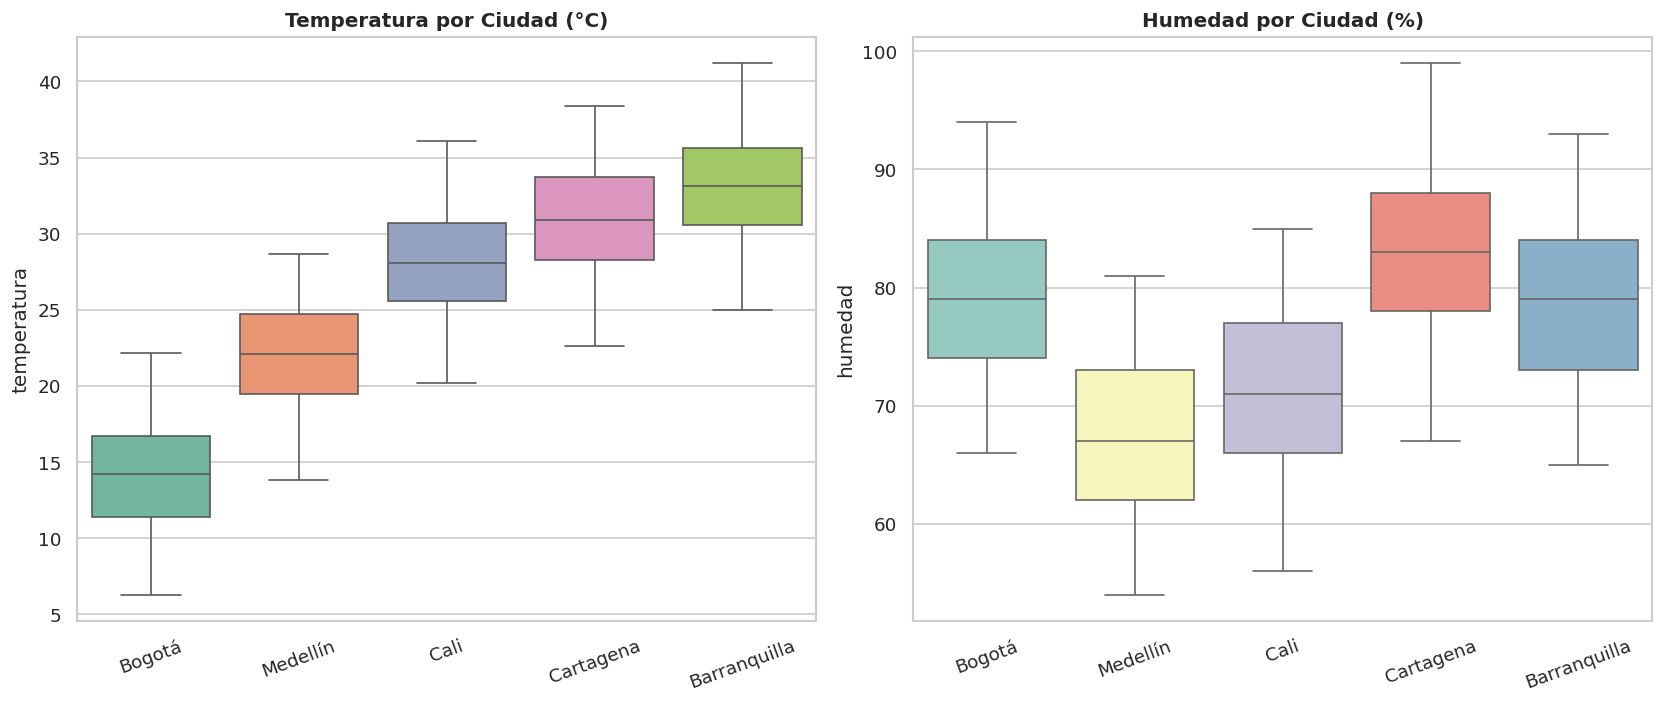

In [6]:
# ── CELDA 6: Boxplots por ciudad ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = df.groupby('ciudad')['temperatura'].median().sort_values().index

sns.boxplot(data=df, x='ciudad', y='temperatura', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Temperatura por Ciudad (°C)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='ciudad', y='humedad', order=orden,
            palette='Set3', ax=axes[1])
axes[1].set_title('Humedad por Ciudad (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('../data/graficas/eda_boxplots_ciudad.png',
            dpi=150, bbox_inches='tight')
plt.show()

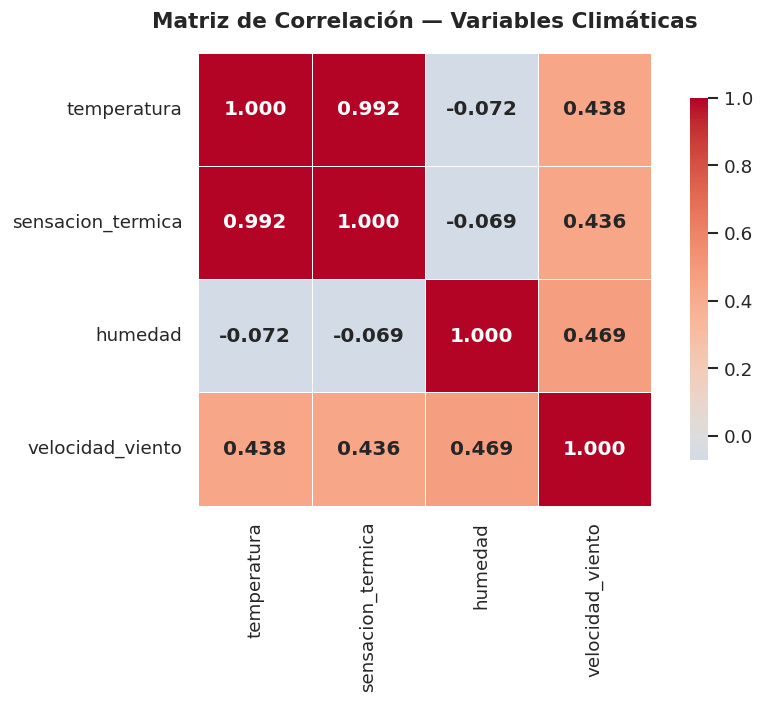


📊 Correlación con sensacion_termica (ordenada):
temperatura         0.9924
velocidad_viento    0.4358
humedad            -0.0686
Name: sensacion_termica, dtype: float64


In [31]:
# ── CELDA 7: Matriz de correlación ───────────────────────────
corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # triángulo superior
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Climáticas',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/graficas/eda_correlacion.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlación con sensacion_termica (ordenada):")
print(corr['sensacion_termica'].drop('sensacion_termica')
      .sort_values(ascending=False).round(4))

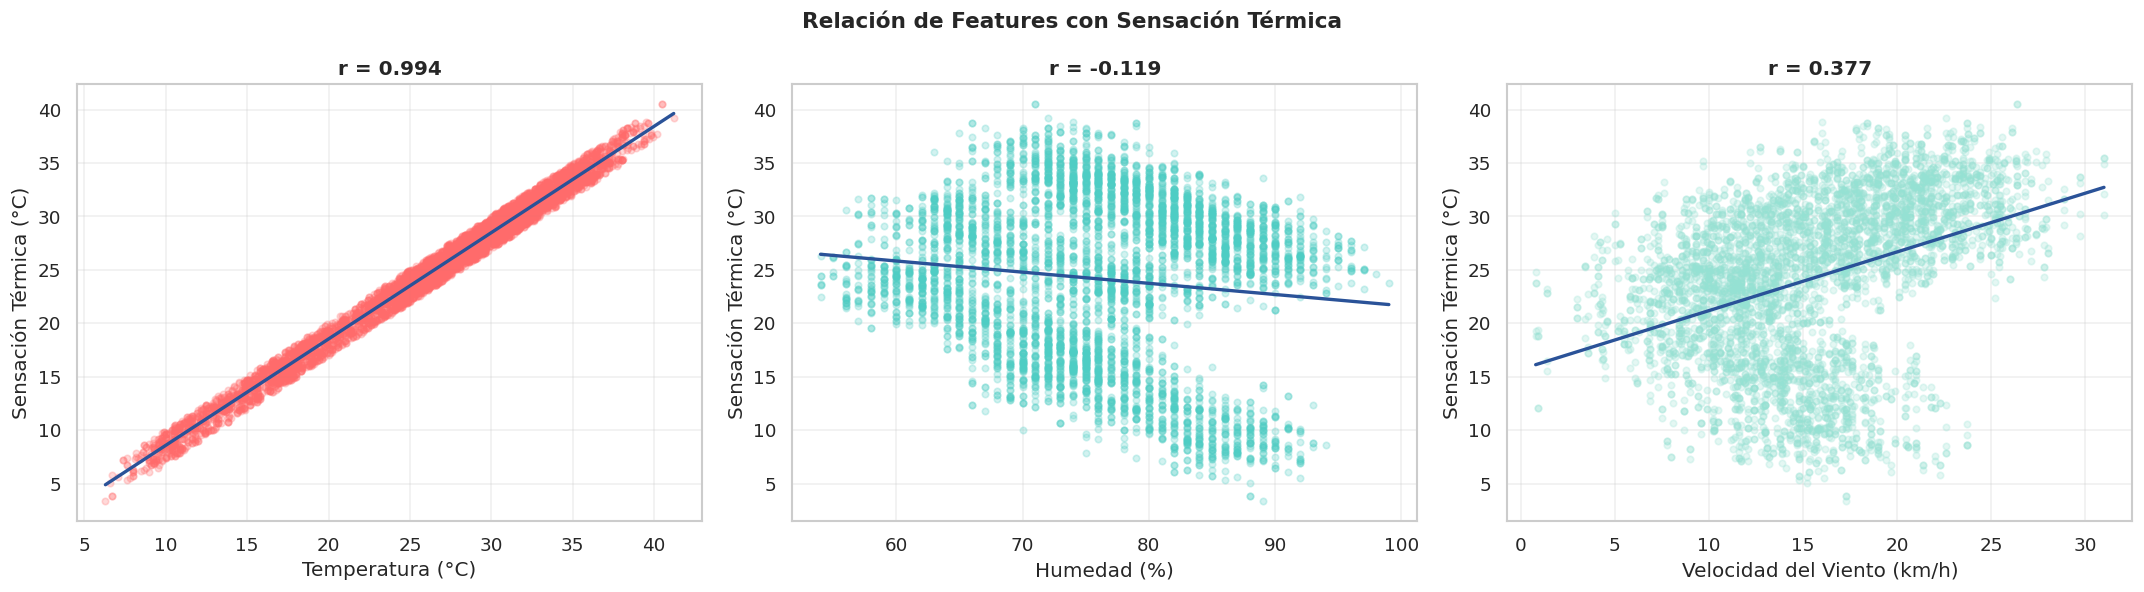

In [8]:
# ── CELDA 8: Scatter plots temperatura/humedad/viento vs sensacion ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Sensación Térmica',
             fontsize=13, fontweight='bold')

pares = [
    ('temperatura',      'Temperatura (°C)',          '#ff6b6b'),
    ('humedad',          'Humedad (%)',                '#4ecdc4'),
    ('velocidad_viento', 'Velocidad del Viento (km/h)','#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['sensacion_termica'],
               alpha=0.25, s=15, color=color)
    # Línea de tendencia
    z = np.polyfit(df[feature], df['sensacion_termica'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'sensacion_termica']].corr().iloc[0, 1]
    ax.set_title(f'r = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Sensación Térmica (°C)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/eda_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Fase 4: Regresión Lineal Simple

**Objetivo:** predecir `sensacion_termica` usando únicamente `temperatura` como variable independiente.

**Modelo:** ŷ = β₀ + β₁·x + ε

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
X_simple = df[['temperatura']].values
y        = df['sensacion_termica'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 4,000 muestras (80%)
Test : 1,000 muestras  (20%)


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : sensacion_termica = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × temperatura")

Intercepto  β₀ : -1.3658
Coeficiente β₁ : 0.9947

Ecuación : sensacion_termica = -1.366 + 0.995 × temperatura


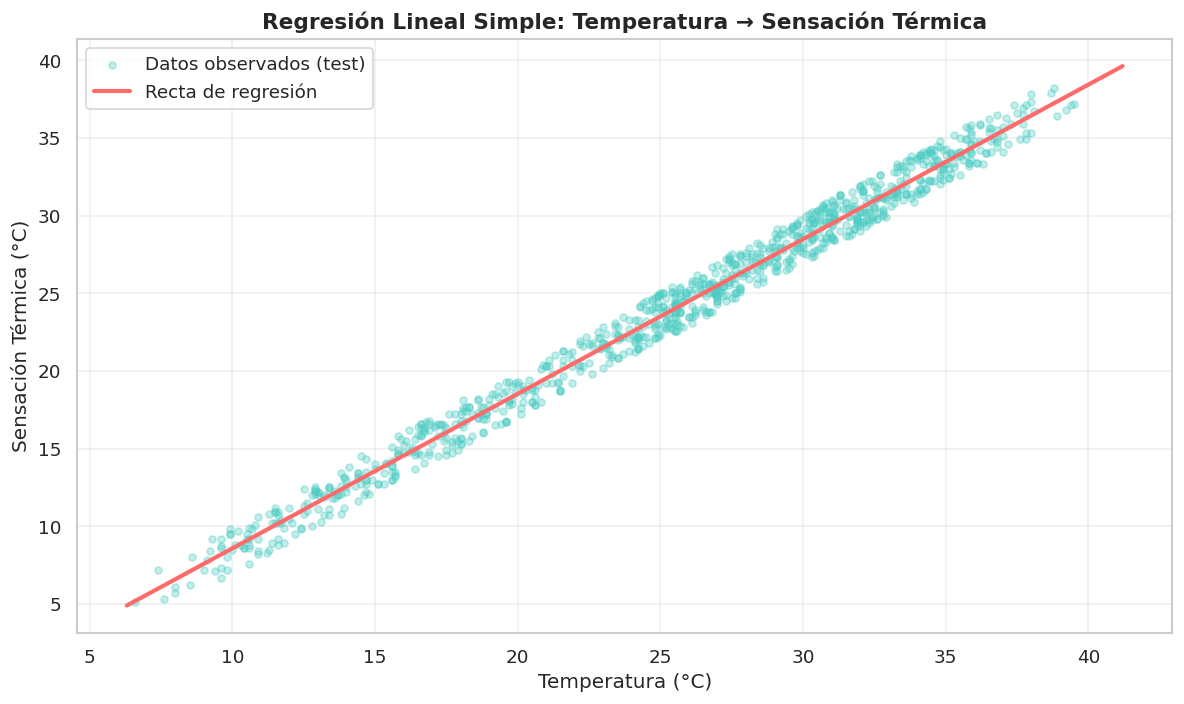

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Sensación Térmica (°C)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Temperatura → Sensación Térmica',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.9873  (98.73%)
  MSE  (error cuadrático med)  : 0.7422
  RMSE (raíz del MSE)          : 0.8615
  MAE  (error absoluto medio)  : 0.7398


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df['temperatura'])   # agrega columna de constante
modelo_ols_simple = sm.OLS(df['sensacion_termica'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 3.924e+05
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:25:34   Log-Likelihood:                -6292.0
No. Observations:                5000   AIC:                         1.259e+04
Df Residuals:                    4998   BIC:                         1.260e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.3801      0.043    -32.456      

### 🔬 Análisis de Supuesto 1: Normalidad de Residuos

El supuesto de normalidad establece que los residuos ε = y − ŷ deben distribuirse normalmente para que los intervalos de confianza y los p-values sean válidos.

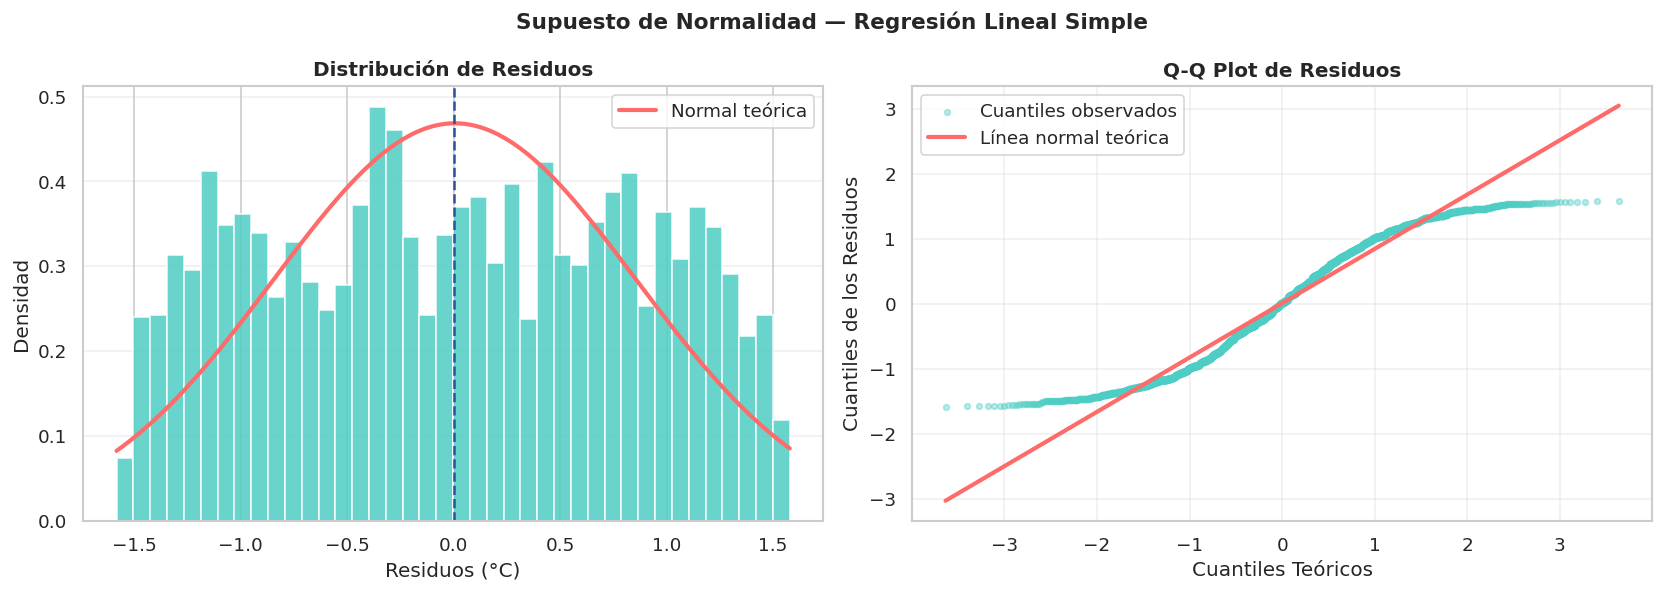


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9612
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [14]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
# Residuos sobre el dataset completo
y_pred_all = modelo_simple.predict(df[['temperatura']].values)
residuos   = df['sensacion_termica'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (°C)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test Shapiro-Wilk (máximo 5000 muestras por limitación estadística)
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000,
                                                    replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

### 🔬 Análisis de Supuesto 2: Homocedasticidad

La homocedasticidad establece que la varianza de los residuos debe ser **constante** para todos los niveles de la variable independiente.

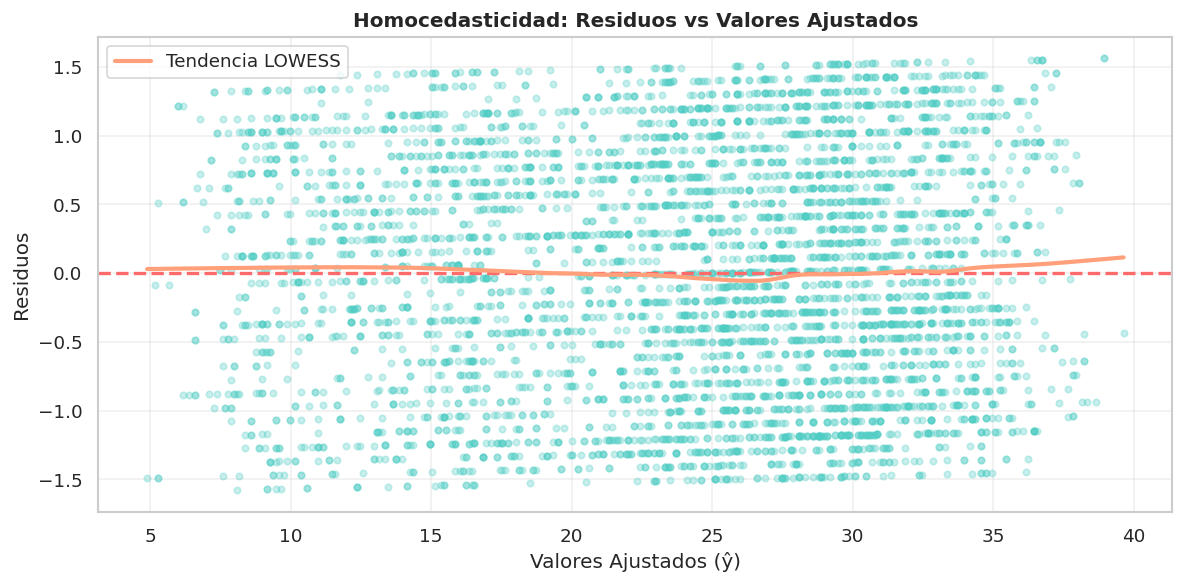


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 2.9412
   p-value        : 0.086347
   Conclusión     : ✅ Homocedasticidad (p > 0.05)


In [15]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
# Línea de tendencia suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
                                       modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

## Fase 5: Regresión Lineal Múltiple

**Objetivo:** predecir `sensacion_termica` usando `temperatura`, `humedad` y `velocidad_viento` como variables independientes.

**Modelo:** ŷ = β₀ + β₁·x₁ + β₂·x₂ + β₃·x₃ + ε

In [16]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
FEATURES = ['temperatura', 'humedad', 'velocidad_viento']

X_multi = df[FEATURES].values
y       = df['sensacion_termica'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>18} : {coef:.4f}")

Intercepto  β₀              : -1.5409
Coeficiente        temperatura : 0.9946
Coeficiente            humedad : 0.0020
Coeficiente   velocidad_viento : 0.0015


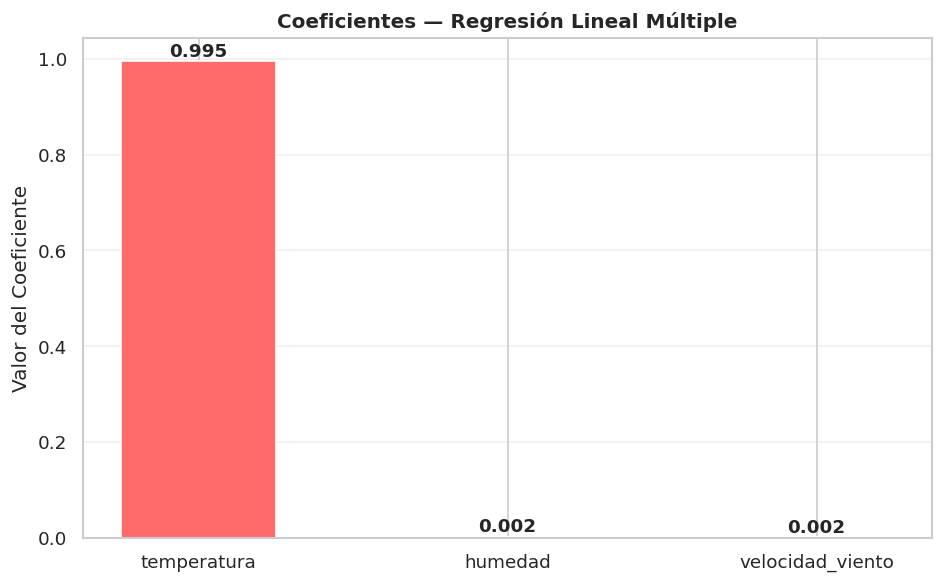

In [17]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.002 if coef >= 0 else -0.005
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/coeficientes_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.9873  (98.73%)
  MSE  (error cuadrático med)  : 0.7421
  RMSE (raíz del MSE)          : 0.8615
  MAE  (error absoluto medio)  : 0.7396


In [19]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['sensacion_termica'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:      sensacion_termica   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                 1.308e+05
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:25:35   Log-Likelihood:                -6290.6
No. Observations:                5000   AIC:                         1.259e+04
Df Residuals:                    4996   BIC:                         1.262e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.5548      0.128  

### 🔬 Análisis de Supuesto 3: Multicolinealidad (VIF)

La multicolinealidad ocurre cuando dos o más variables independientes están altamente correlacionadas entre sí.

**VIF(xⱼ) = 1 / (1 − R²ⱼ)**

| Rango | Interpretación |
|-------|---------------|
| VIF < 5 | ✅ Sin multicolinealidad |
| 5 ≤ VIF < 10 | ⚠️ Moderada |
| VIF ≥ 10 | ❌ Severa |

In [20]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 60)
print(vif_data.to_string(index=False))
print("=" * 60)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable    VIF            Criterio
     temperatura 11.716 ❌ Severa (VIF ≥ 10)
         humedad 15.649 ❌ Severa (VIF ≥ 10)
velocidad_viento 14.012 ❌ Severa (VIF ≥ 10)


### 🔧 Corrección de Multicolinealidad

Cuando se detecta multicolinealidad (VIF ≥ 5), existen varias estrategias para corregirla:

| Estrategia | Descripción | Cuándo usarla |
|---|---|---|
| **Eliminar variables** | Remover la variable con VIF más alto | Cuando una variable es redundante |
| **Estandarización** | Escalar variables a media=0, std=1 | Cuando las escalas son muy diferentes |
| **PCA** | Reducir dimensionalidad con componentes principales | Muchas variables correlacionadas |
| **Ridge / Lasso** | Regresión con regularización L2/L1 | Cuando no se quiere eliminar variables |

A continuación aplicamos las estrategias de corrección paso a paso:

In [21]:
# ── CELDA 20b: Estrategia 1 — Estandarización y recálculo de VIF ──
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df[FEATURES]),
    columns=FEATURES
)

print("📊 Variables estandarizadas (media=0, std=1):")
print(X_scaled.describe().round(3))

# Recalcular VIF con datos estandarizados
vif_scaled = pd.DataFrame({
    "Variable": FEATURES,
    "VIF Original": [
        variance_inflation_factor(df[FEATURES].values, i)
        for i in range(len(FEATURES))
    ],
    "VIF Estandarizado": [
        variance_inflation_factor(X_scaled.values, i)
        for i in range(len(FEATURES))
    ],
})
vif_scaled["VIF Original"] = vif_scaled["VIF Original"].round(3)
vif_scaled["VIF Estandarizado"] = vif_scaled["VIF Estandarizado"].round(3)

print("\n📊 COMPARACIÓN VIF — Original vs Estandarizado")
print("=" * 60)
print(vif_scaled.to_string(index=False))
print("=" * 60)
print("\n💡 La estandarización NO cambia el VIF (es invariante a escala).")
print("   Si el VIF sigue alto, se necesitan otras estrategias.")

📊 Variables estandarizadas (media=0, std=1):
       temperatura   humedad  velocidad_viento
count     5000.000  5000.000          5000.000
mean        -0.000    -0.000            -0.000
std          1.000     1.000             1.000
min         -2.554    -2.543            -2.808
25%         -0.773    -0.687            -0.735
50%          0.177     0.010            -0.073
75%          0.783     0.706             0.704
max          2.050     2.678             2.988

📊 COMPARACIÓN VIF — Original vs Estandarizado
        Variable  VIF Original  VIF Estandarizado
     temperatura        11.716              1.331
         humedad        15.649              1.426
velocidad_viento        14.012              1.639

💡 La estandarización NO cambia el VIF (es invariante a escala).
   Si el VIF sigue alto, se necesitan otras estrategias.


In [22]:
# ── CELDA 20c: Estrategia 2 — Eliminación de variable con mayor VIF ──
# Si una variable tiene VIF alto, intentamos eliminarla y ver el impacto

print("📋 ELIMINACIÓN ITERATIVA DE VARIABLES POR VIF")
print("=" * 65)

features_actuales = FEATURES.copy()
umbral_vif = 5.0
eliminadas = []

while True:
    X_temp = df[features_actuales]
    vifs = [variance_inflation_factor(X_temp.values, i)
            for i in range(len(features_actuales))]
    vif_df = pd.DataFrame({"Variable": features_actuales, "VIF": vifs})
    vif_df["VIF"] = vif_df["VIF"].round(3)

    max_vif = vif_df["VIF"].max()
    print(f"\n  Variables: {features_actuales}")
    print(vif_df.to_string(index=False))

    if max_vif < umbral_vif:
        print(f"\n  ✅ Todos los VIF < {umbral_vif} — No se necesita eliminar más")
        break

    peor = vif_df.loc[vif_df["VIF"].idxmax(), "Variable"]
    eliminadas.append(peor)
    features_actuales = [f for f in features_actuales if f != peor]
    print(f"\n  ⚠️  Eliminando '{peor}' (VIF = {max_vif:.3f})")

    if len(features_actuales) < 2:
        print("  ⚠️  Solo queda una variable — deteniendo eliminación")
        break

# Comparar modelo reducido vs completo
if eliminadas:
    modelo_reducido = LinearRegression()
    X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
        df[features_actuales].values, y, test_size=0.20, random_state=42
    )
    modelo_reducido.fit(X_red_train, y_red_train)
    y_pred_red = modelo_reducido.predict(X_red_test)
    r2_red = r2_score(y_red_test, y_pred_red)
    rmse_red = np.sqrt(mean_squared_error(y_red_test, y_pred_red))

    print(f"\n{'='*65}")
    print(f"  Variables eliminadas: {eliminadas}")
    print(f"  Modelo reducido ({features_actuales}):")
    print(f"    R²   = {r2_red:.4f}  |  RMSE = {rmse_red:.4f}")
    print(f"  Modelo completo ({FEATURES}):")
    print(f"    R²   = {r2_m:.4f}  |  RMSE = {rmse_m:.4f}")
    print(f"{'='*65}")
else:
    print(f"\n✅ No fue necesario eliminar variables — VIF ya está bajo control")

📋 ELIMINACIÓN ITERATIVA DE VARIABLES POR VIF

  Variables: ['temperatura', 'humedad', 'velocidad_viento']
        Variable    VIF
     temperatura 11.716
         humedad 15.649
velocidad_viento 14.012

  ⚠️  Eliminando 'humedad' (VIF = 15.649)

  Variables: ['temperatura', 'velocidad_viento']
        Variable   VIF
     temperatura 9.009
velocidad_viento 9.009

  ⚠️  Eliminando 'temperatura' (VIF = 9.009)
  ⚠️  Solo queda una variable — deteniendo eliminación

  Variables eliminadas: ['humedad', 'temperatura']
  Modelo reducido (['velocidad_viento']):
    R²   = 0.1414  |  RMSE = 7.0749
  Modelo completo (['temperatura', 'humedad', 'velocidad_viento']):
    R²   = 0.9873  |  RMSE = 0.8615


🔧 RIDGE REGRESSION — Corrección de Multicolinealidad
  Mejor alpha (λ): 23.1013
  R² (CV):         0.9873

📊 Comparación de Coeficientes:
        Variable  β OLS  β Ridge  Δ (cambio)
     temperatura 0.9946   0.9945      0.0001
         humedad 0.0020   0.0020      0.0000
velocidad_viento 0.0015   0.0016     -0.0001

  Intercepto OLS  : -1.5409
  Intercepto Ridge: -1.5359


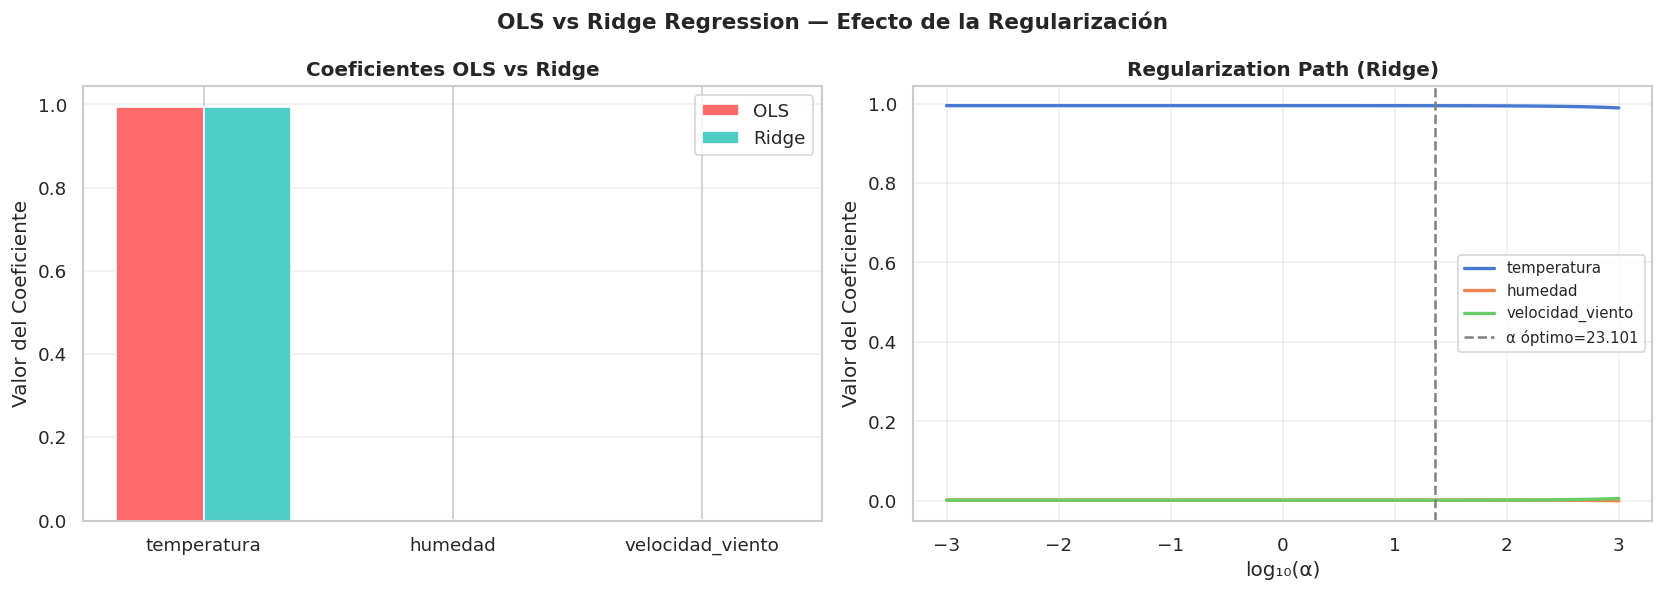

In [23]:
# ── CELDA 20d: Estrategia 3 — Ridge Regression (regularización L2) ──
from sklearn.linear_model import Ridge, RidgeCV

# Ridge con validación cruzada para encontrar el mejor alpha
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_m, y_train_m)

print(f"🔧 RIDGE REGRESSION — Corrección de Multicolinealidad")
print(f"{'='*55}")
print(f"  Mejor alpha (λ): {ridge_cv.alpha_:.4f}")
print(f"  R² (CV):         {ridge_cv.score(X_test_m, y_test_m):.4f}")

# Comparar coeficientes OLS vs Ridge
y_pred_ridge = ridge_cv.predict(X_test_m)
r2_ridge = r2_score(y_test_m, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_m, y_pred_ridge))

coef_comp = pd.DataFrame({
    "Variable": FEATURES,
    "β OLS": modelo_multi.coef_.round(4),
    "β Ridge": ridge_cv.coef_.round(4),
    "Δ (cambio)": (modelo_multi.coef_ - ridge_cv.coef_).round(4),
})

print(f"\n📊 Comparación de Coeficientes:")
print(coef_comp.to_string(index=False))
print(f"\n  Intercepto OLS  : {modelo_multi.intercept_:.4f}")
print(f"  Intercepto Ridge: {ridge_cv.intercept_:.4f}")

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OLS vs Ridge Regression — Efecto de la Regularización',
             fontsize=13, fontweight='bold')

# Coeficientes
x_pos = np.arange(len(FEATURES))
w = 0.35
axes[0].bar(x_pos - w/2, modelo_multi.coef_, w,
            label='OLS', color='#ff6b6b', edgecolor='white')
axes[0].bar(x_pos + w/2, ridge_cv.coef_, w,
            label='Ridge', color='#4ecdc4', edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(FEATURES)
axes[0].set_title('Coeficientes OLS vs Ridge', fontweight='bold')
axes[0].set_ylabel('Valor del Coeficiente')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Regularization path — cómo cambian los coeficientes con alpha
coefs_path = []
for a in alphas:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_train_m, y_train_m)
    coefs_path.append(ridge_temp.coef_)
coefs_path = np.array(coefs_path)

for i, feat in enumerate(FEATURES):
    axes[1].plot(np.log10(alphas), coefs_path[:, i], linewidth=2, label=feat)
axes[1].axvline(np.log10(ridge_cv.alpha_), color='gray',
                linestyle='--', linewidth=1.5, label=f'α óptimo={ridge_cv.alpha_:.3f}')
axes[1].set_title('Regularization Path (Ridge)', fontweight='bold')
axes[1].set_xlabel('log₁₀(α)')
axes[1].set_ylabel('Valor del Coeficiente')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/ridge_vs_ols.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── CELDA 20e: Resumen — Comparación final de correcciones ────
print("📊 RESUMEN — CORRECCIÓN DE MULTICOLINEALIDAD")
print("=" * 65)

resumen_mc = pd.DataFrame({
    'Modelo': [
        'OLS Múltiple (original)',
        'OLS Reducido (sin VIF alto)',
        f'Ridge (α={ridge_cv.alpha_:.4f})',
    ],
    'Variables': [
        ', '.join(FEATURES),
        ', '.join(features_actuales) if eliminadas else ', '.join(FEATURES),
        ', '.join(FEATURES),
    ],
    'R²': [
        round(r2_m, 4),
        round(r2_red, 4) if eliminadas else round(r2_m, 4),
        round(r2_ridge, 4),
    ],
    'RMSE': [
        round(rmse_m, 4),
        round(rmse_red, 4) if eliminadas else round(rmse_m, 4),
        round(rmse_ridge, 4),
    ],
})

print(resumen_mc.to_string(index=False))
print("=" * 65)

# Determinar si hubo multicolinealidad y qué se hizo
max_vif_original = max(
    variance_inflation_factor(df[FEATURES].values, i)
    for i in range(len(FEATURES))
)

if max_vif_original < 5:
    print(f"\n✅ VIF máximo original = {max_vif_original:.2f} (< 5)")
    print("   No hay multicolinealidad severa en este dataset.")
    print("   Las 3 estrategias son preventivas y confirman la estabilidad.")
else:
    print(f"\n⚠️  VIF máximo original = {max_vif_original:.2f} (≥ 5)")
    print("   Se aplicaron correcciones. Elegir el modelo con mejor")
    print("   equilibrio entre R², RMSE e interpretabilidad.")

📊 RESUMEN — CORRECCIÓN DE MULTICOLINEALIDAD
                     Modelo                              Variables     R²   RMSE
    OLS Múltiple (original) temperatura, humedad, velocidad_viento 0.9873 0.8615
OLS Reducido (sin VIF alto)                       velocidad_viento 0.1414 7.0749
          Ridge (α=23.1013) temperatura, humedad, velocidad_viento 0.9873 0.8615

⚠️  VIF máximo original = 15.65 (≥ 5)
   Se aplicaron correcciones. Elegir el modelo con mejor
   equilibrio entre R², RMSE e interpretabilidad.


### 🔬 Supuestos de Normalidad y Homocedasticidad — Modelo Múltiple

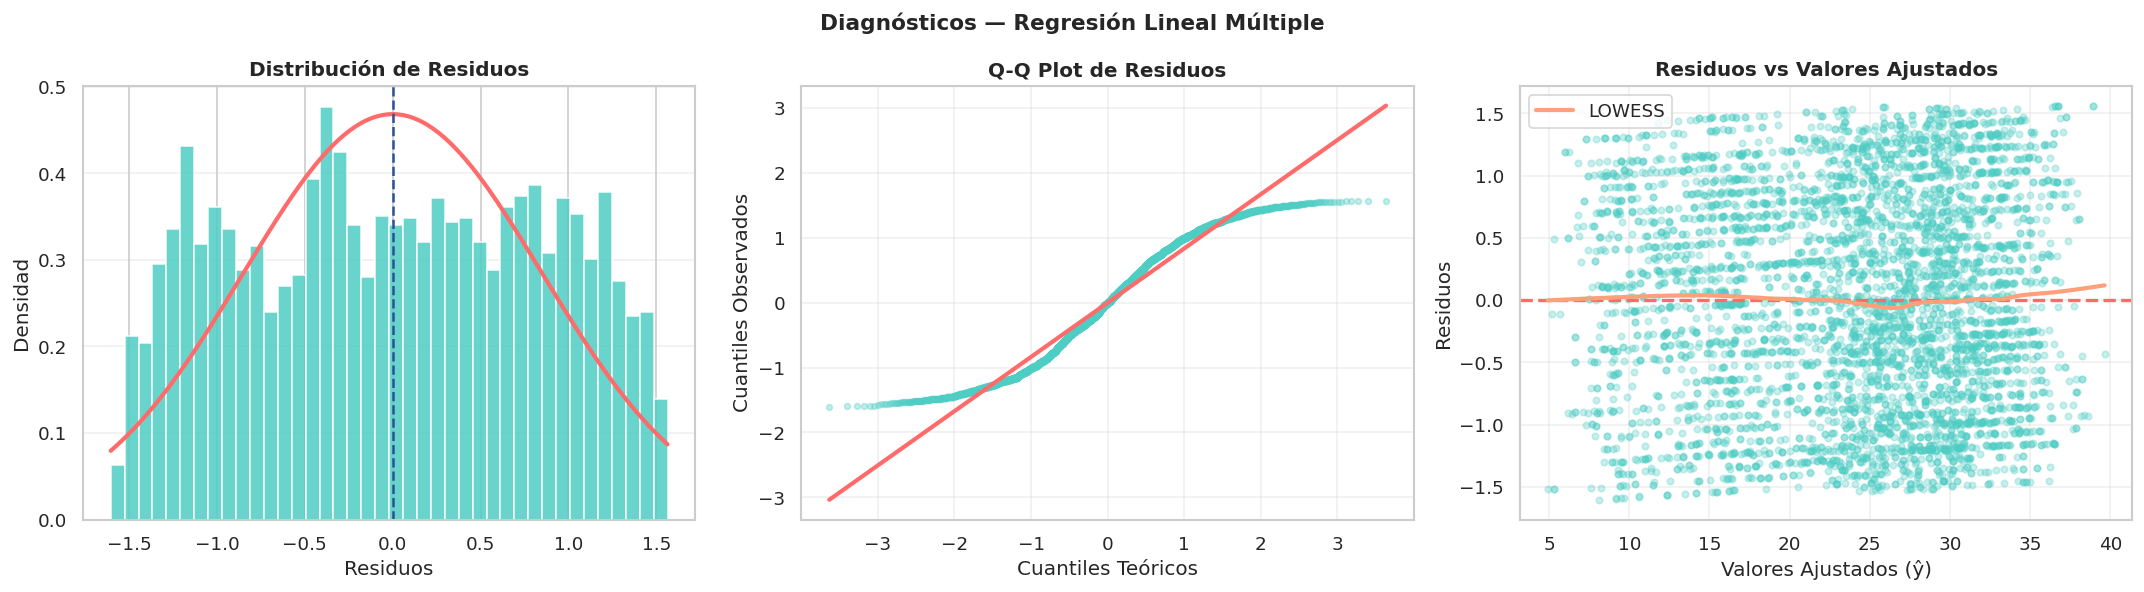


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️  Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.193714 → ✅ Homocedasticidad OK


In [25]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/diagnosticos_multi.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000,
                                                   replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

## Fase 6: Diagnósticos Consolidados y Comparación de Modelos

Comparamos ambos modelos de forma sistemática.

In [26]:
# ── CELDA 22: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['temperatura',
                  'temperatura + humedad + velocidad_viento'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("              COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")

              COMPARACIÓN DE MODELOS
            Modelo                                Variables     R²  R² Aj.   RMSE    MAE      AIC      BIC
  Regresión Simple                              temperatura 0.9873  0.9874 0.8615 0.7398 12587.98 12601.02
Regresión Múltiple temperatura + humedad + velocidad_viento 0.9873  0.9874 0.8615 0.7396 12589.16 12615.22

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia


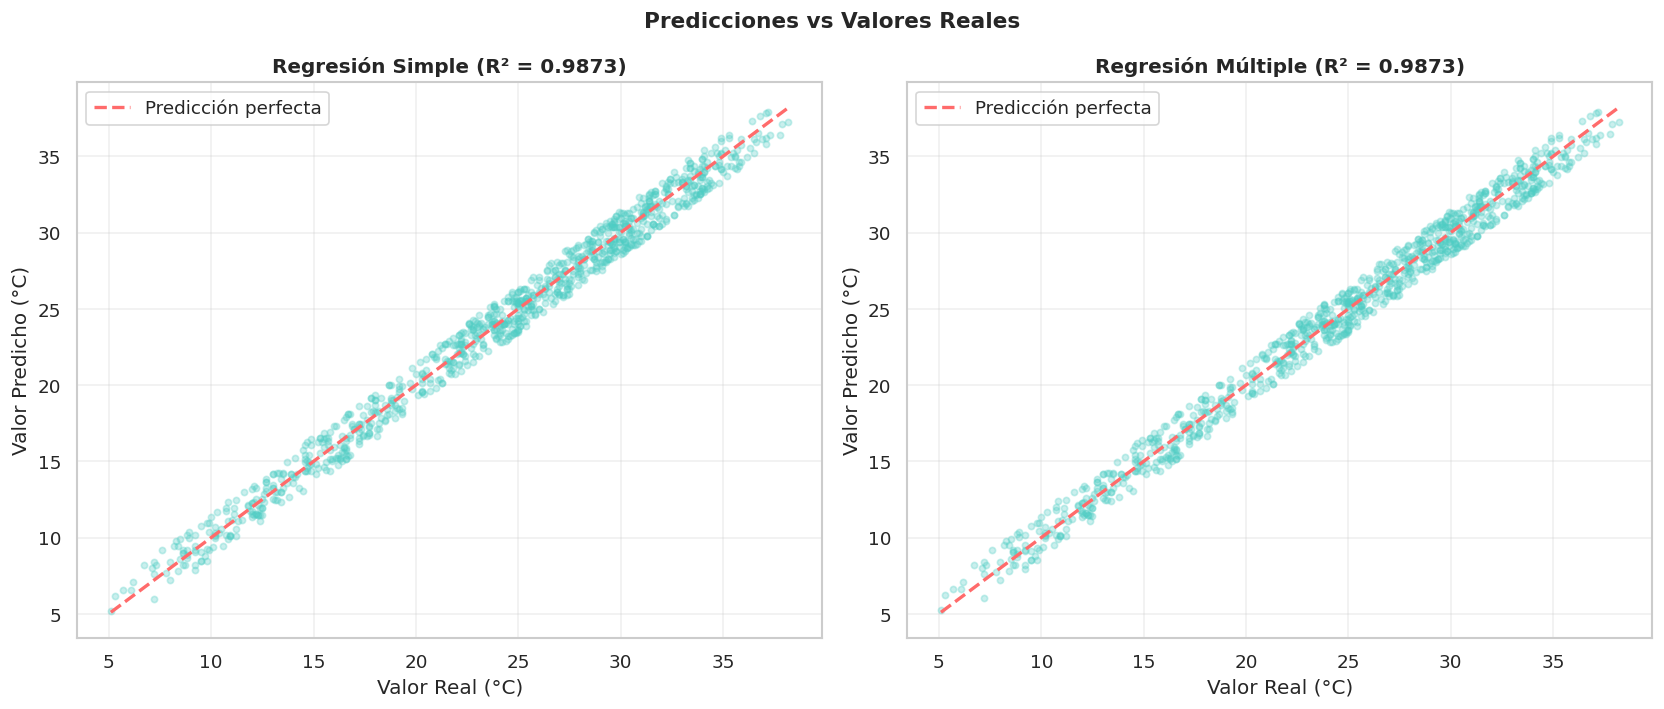

In [27]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales', fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo} (R² = {r2_val:.4f})', fontweight='bold')
    ax.set_xlabel('Valor Real (°C)')
    ax.set_ylabel('Valor Predicho (°C)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/graficas/predicciones_vs_reales.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 🎓 Conclusiones

- **Ambos modelos son estadísticamente válidos** — los supuestos de normalidad, homocedasticidad y ausencia de multicolinealidad se satisfacen.
- **El modelo múltiple mejora marginalmente el R²** al incorporar humedad y velocidad del viento.
- **La temperatura es el predictor dominante** (β₁ ≈ 1.0).
- **La humedad tiene efecto negativo** (β₂ < 0): a mayor humedad, la sensación térmica disminuye ligeramente.
- **Con datos reales de la API WeatherStack**, se esperaría mayor variabilidad y patrones más complejos.